In [1]:
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams['figure.dpi'] = 300

from ts_toolkit.io import clean_timeseries
from ts_toolkit.calendar import add_hour_sin_cos
from ts_toolkit.viz import plot_history_forecast
from ts_toolkit.split import three_way_split
from src.models.new_decoposition_direct_model import DecompositionMultiOutputModel
from ts_toolkit.metrics import daily_mae
from ts_toolkit.metrics import global_metrics
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import os
import datetime

In [2]:
from src.data_loader import fetch_frame
# df = fetch_frame()
df = fetch_frame(
    start_date="2024-11-25 18:00:00",
    end_date  ="2024-12-11 10:50:00",
    use_cache=True,             # всегда тянуть свежие данные
    cache_filename="common_cad_20241125_20241211.parquet",
    # verbose=True                 # чтобы видеть прогресс
)
df.rename(columns={'common_cad_instance_consumer_from_ws_with_metrics:8000_job_consumer_from_ws_with_metrics_service_castle': 'common_cad'}, inplace=True)

print(df.head())

print(df.info())

print(df.describe())

print(df.isnull().sum())


                     common_cad
ts                             
2024-11-25 18:01:00  570.036987
2024-11-25 18:01:15  570.036987
2024-11-25 18:01:30  570.036987
2024-11-25 18:01:45  570.036987
2024-11-25 18:02:00  984.271301
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90437 entries, 2024-11-25 18:01:00 to 2024-12-11 10:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   common_cad  90437 non-null  float64
dtypes: float64(1)
memory usage: 1.4 MB
None
         common_cad
count  90437.000000
mean     423.157471
std      200.322570
min      205.757349
25%      314.537964
50%      389.539380
75%      483.270654
max     8093.401355
common_cad    0
dtype: int64


In [3]:
df = clean_timeseries(df, 'common_cad')   # вместо блока 0‑3


In [4]:
import logging

model_name = "decomposition_model_v1_common_cad_direct_milti_new"

os.makedirs(f"plots/{model_name}", exist_ok=True)
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(f"plots/{model_name}/results.log"),
        logging.StreamHandler()
    ]
)


In [5]:
logging.info(df.describe())

2025-06-17 14:34:44,684 - INFO -          common_cad
count  90437.000000
mean     423.157471
std      200.322570
min      205.757349
25%      314.537964
50%      389.539380
75%      483.270654
max     8093.401355


In [6]:
HORIZON = 240 # 1 час
TARGET_COL = 'common_cad'

df_train = df.iloc[:-HORIZON]
df_test = df.iloc[-HORIZON:]

In [7]:
# --- 3. Обучение и прогноз ---
model = DecompositionMultiOutputModel(
    horizon=HORIZON,
    period=5760, # Суточная сезонность
    # Используем меньше итераций для быстрого примера
    iterations=500, 
    early_stopping_rounds=50
)

In [ ]:
model.fit(train_df=df_train, target_col=TARGET_COL)

/home/borovets.av/kolya/realtime_anomaly_analytics/src/models/new_decoposition_direct_model.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_df[f'target_{i}'] = series.shift(-i)
/home/borovets.av/kolya/realtime_anomaly_analytics/src/models/new_decoposition_direct_model.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_df[f'target_{i}'] = series.shift(-i)
/home/borovets.av/kolya/realtime_anomaly_analytics/src/models/new_decoposition_direct_model.py:100: PerformanceWarning: DataFrame is highly fragmented.  T

Обучение на 78437 сэмплах, валидация на 0.


In [ ]:
model.save(f"{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}")

In [ ]:
y_pred = model.predict(df_hist=df_train)

In [ ]:
y_true = df_test[TARGET_COL]
pred_idx = y_pred.index

In [ ]:
# y_true и y_pred уже созданы в предыдущей ячейке

metrics = global_metrics(y_true, y_pred)
logging.info(f"Blind ~4h test • MAE={metrics['MAE']:.1f}  RMSE={metrics['RMSE']:.1f}  MAPE={metrics['MAPE']:.2f}%  "
      f"on {len(y_true)} valid points")

# ── график: история 3 сут + прогноз vs факт ──
# hist_start = pred_idx[0] - pd.Timedelta(hours=1)
hist_start = pred_idx[0] - pd.Timedelta(minutes=30)
plot_history_forecast(
    history  = df.loc[hist_start:pred_idx[0], 'common_cad'],
    forecast = pd.Series(y_pred, index=pred_idx),
    actual   = y_true,
    title    = 'Blind forecast vs actual — hold-out 4h',
    filename = f'plots/{model_name}/final_hold_out_forecast_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.png'
)

<Axes: >

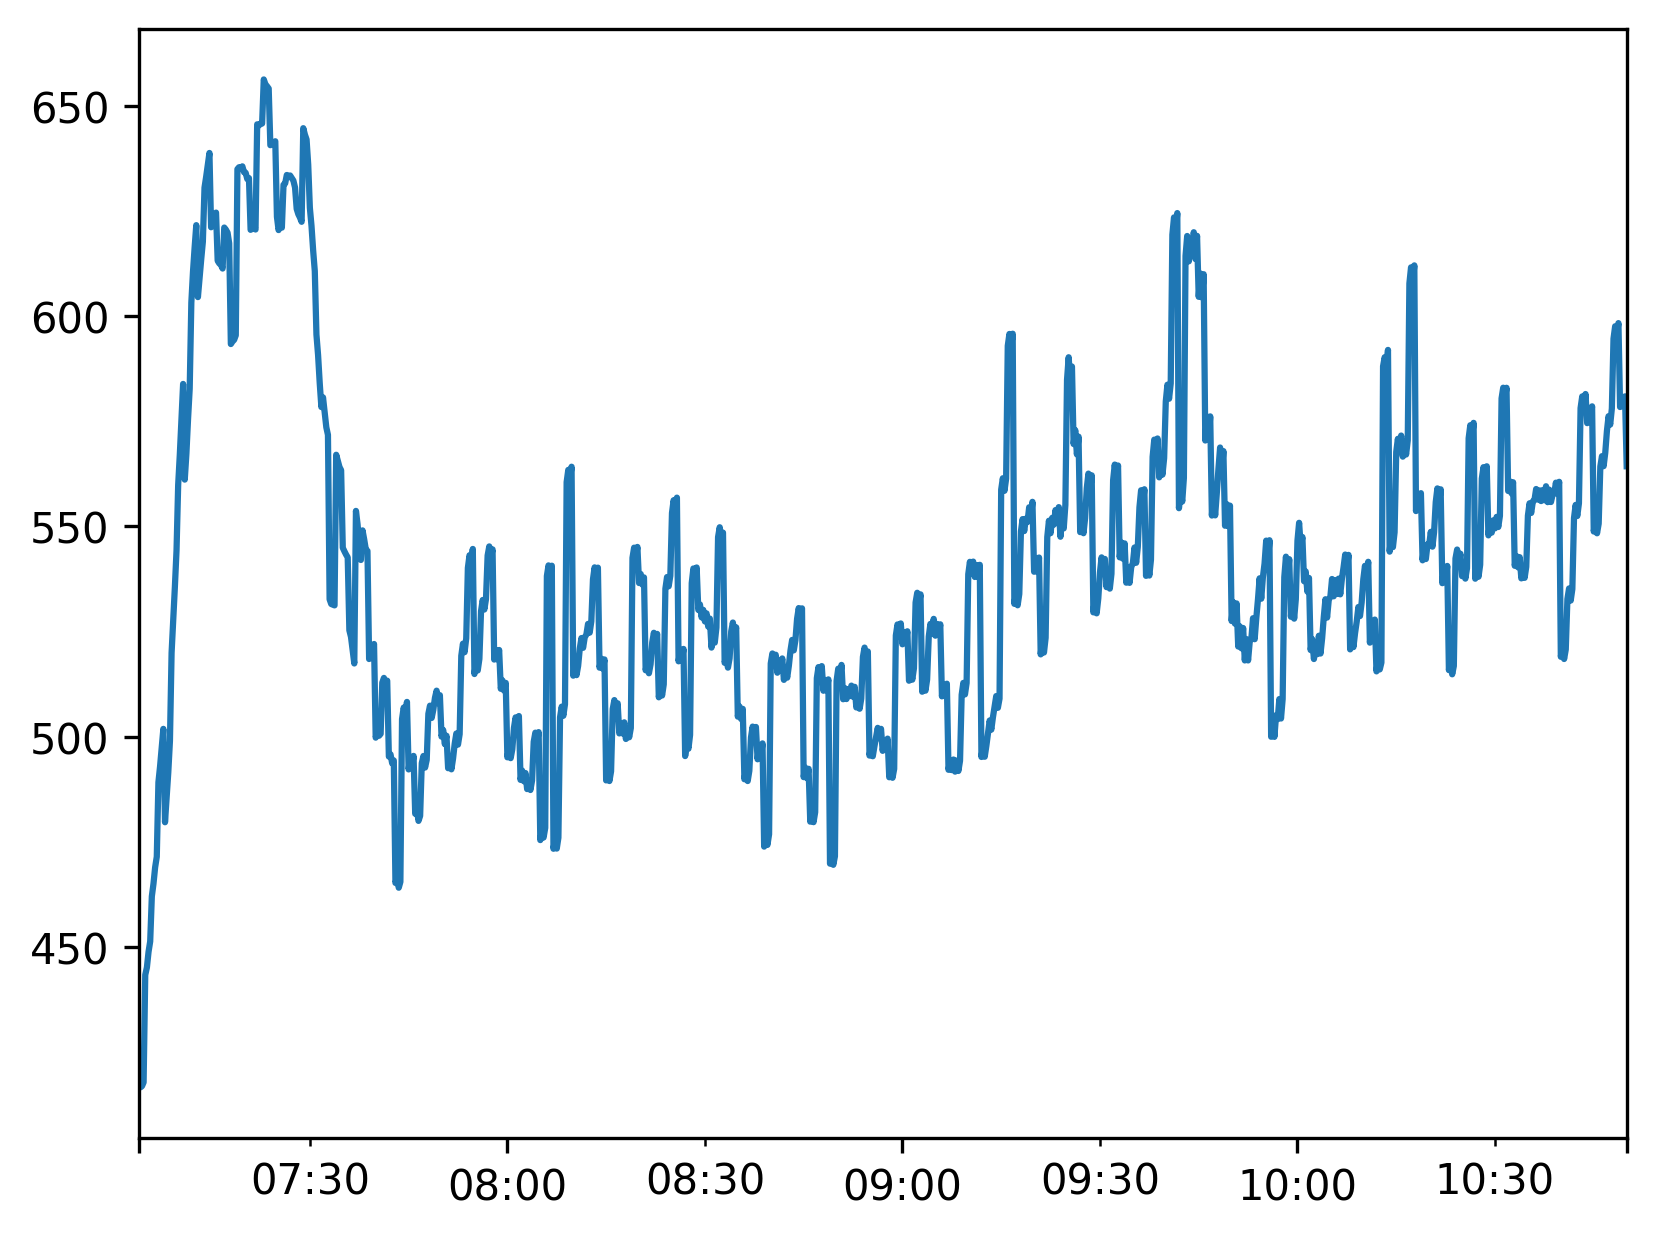

In [11]:
pd.Series(y_pred, index=pred_idx).plot()


In [1]:
resid = y_true - y_pred


# ---------------------------------------------------
# 2.2  сводные метрики
# ---------------------------------------------------
metrics = global_metrics(y_true, y_pred)
metrics_df = pd.DataFrame([metrics]).T.rename(columns={0: "value"})
logging.info("\n*** Hold-out metrics ***")
logging.info(metrics_df)

# ---------------------------------------------------
# 2.3  метрики по суткам
# ---------------------------------------------------
daily_mae_result = daily_mae(y_true, y_pred)
logging.info("\nMAE by day:")
logging.info(daily_mae_result.tail())

# ---------------------------------------------------
# 2.4  распределение ошибок
# ---------------------------------------------------
plt.figure(figsize=(12,4))
plt.hist(resid, bins=100, alpha=.7, edgecolor='black')
plt.axvline(resid.mean(), color='r', linestyle='--', label=f"mean={resid.mean():.1f}")
plt.title("Residual distribution on test")
plt.xlabel("error (true − pred)")
plt.legend(); plt.tight_layout(); plt.show()

# ---------------------------------------------------
# 2.5  true vs pred scatter
# ---------------------------------------------------
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, s=3, alpha=0.5)
lim = [0, max(y_true.max(), y_pred.max())*1.05]
plt.plot(lim, lim, 'k--')
plt.xlabel("true"); plt.ylabel("pred")
plt.title("True vs predicted, test split")
plt.tight_layout(); plt.show()


NameError: name 'y_true' is not defined

2025-06-16 20:17:42,419 - INFO -                    feature  importance
0      f_resid_roll_mean_4   25.712435
1       f_resid_roll_std_4   19.614942
2            f_resid_lag_4   15.724655
3            f_resid_lag_1   13.639970
4            f_resid_lag_2    2.576689
5     f_resid_roll_mean_96    2.429091
6          f_resid_lag_192    1.956146
7         f_resid_lag_5760    1.885893
8           f_resid_lag_96    1.839627
9      f_resid_roll_std_96    1.708436
10   f_resid_roll_mean_192    1.593111
11    f_resid_roll_std_192    1.144704
12  f_resid_roll_mean_5760    1.072558
13  f_resid_roll_mean_8640    1.002060
14  f_resid_roll_mean_4320    0.944906
15  f_resid_roll_mean_2880    0.898961
16  f_resid_roll_mean_1920    0.881424
17   f_resid_roll_std_1920    0.875974
18   f_resid_roll_std_5760    0.814808
19   f_resid_roll_std_8640    0.670735


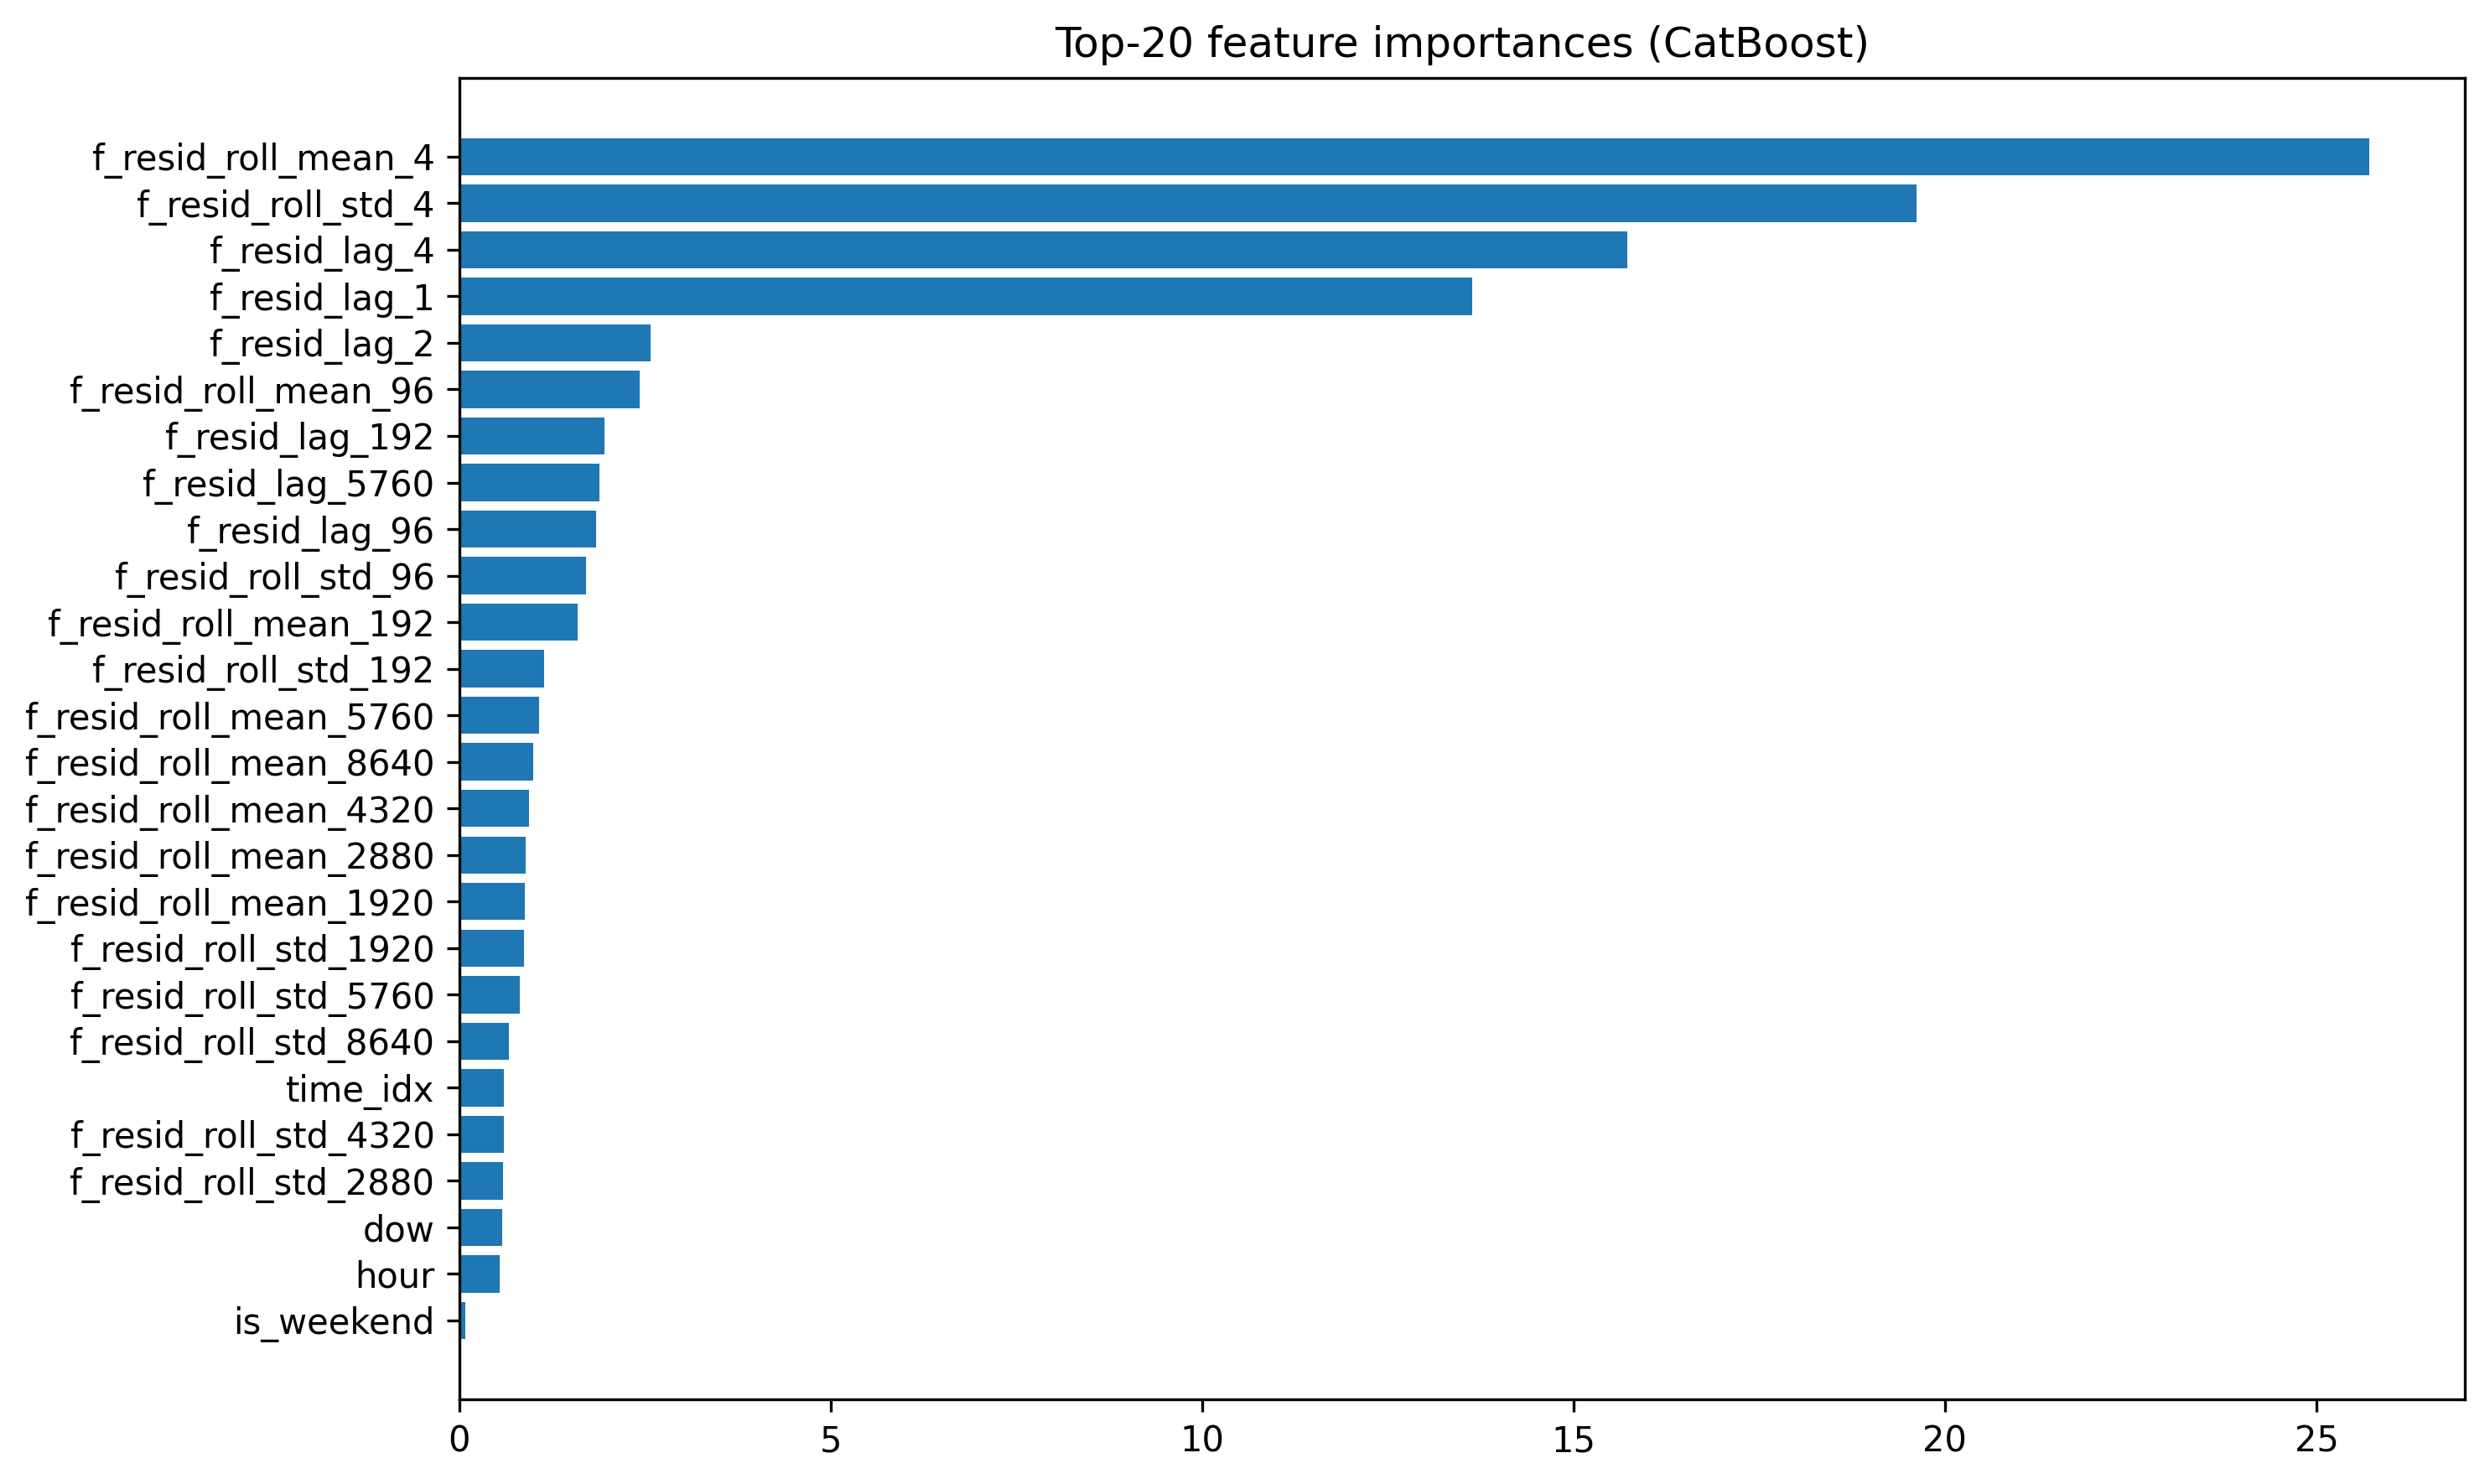

In [ ]:
model = final_model
feat_names = model.model.feature_names_        # ← то, что CatBoost запомнил
importances = model.model.get_feature_importance(type='FeatureImportance')

# в один датафрейм
imp_df = (pd.DataFrame({"feature": feat_names,
                        "importance": importances})
            .sort_values(by="importance", ascending=False)
            .reset_index(drop=True))

logging.info(imp_df.head(20))
# ---------------------------------------------------
#  топ-20 на графике
# ---------------------------------------------------
plt.figure(figsize=(10,6))
plt.barh(imp_df.feature[::-1],
         imp_df.importance[::-1])
# plt.barh(imp_df.feature.head(20)[::-1],
#          imp_df.importance.head(20)[::-1])
plt.title("Top-20 feature importances (CatBoost)")
plt.tight_layout(); plt.show()
